<h1>Analyse Emotionnelle: DataCleaning & Preprocessing</h1>

<h3>Classement des emotion</h3>
<ul>
   <li>1- Joie - beaucoup d'échantillons: 140779.</li>
<li>0 - Tristesse - un bon volume d'échantillon: 120989.</li>
<li>3 - Colère - un volume moyen d'échantillon: 57235</li>
<li>4 - Peur - peu d'échantillons: 47664</li>
<li>2 - Amour - peu d'échantillons: 34497.</li>
<li>5 - Surprise - Très peu d'échantillons: 14959</li>
</ul>

<h2>Data Cleaning</h2>

In [33]:
#Importation des librairies
import numpy as np
import pandas as pd
from collections import Counter
import re
import warnings
warnings.filterwarnings("ignore")

In [34]:
url_emotion_txt_df = r"../Datasets/EmotionTexteDataset/emotions.csv"
url_sentiment_df = r"../Datasets/SentimentDataset/training.1600000.processed.noemoticon.csv"

In [35]:
#Lecture des deux Dataframes
df_emotion_txt = pd.read_csv(url_emotion_txt_df)
df_sentiment = pd.read_csv(url_sentiment_df, encoding = "latin-1")

In [36]:
#Copie du dataset d'origine
copy_df_emotion_txt = df_emotion_txt.copy()

In [37]:
copy_df_emotion_txt.head()

,text,label
0,i just feel really helpless and heavy hearted,4
1,ive enjoyed being able to slouch about relax a...,0
2,i gave up my internship with the dmrg and am f...,4
3,i dont know i feel so lost,0
4,i am a kindergarten teacher and i am thoroughl...,4


<h2>DataCleanning</h2>

In [38]:
#Enlever les valeurs manquantes
copy_df_emotion_txt.drop_duplicates(inplace = True)

In [39]:
copy_df_emotion_txt.duplicated().sum()

0

In [40]:
#Suppression des caractères spéciaux
copy_df_emotion_txt["text"] = copy_df_emotion_txt["text"].astype(str).str.replace(r"[^a-zA-Z0-9À-ÖØ-öø-ÿ\s.,!?;:'\"()-]", "", regex = True)

In [41]:
#Nombre total de text
print(copy_df_emotion_txt.info())
print("\n")
print(copy_df_emotion_txt.index.max())
print(copy_df_emotion_txt.index.min())

<class 'pandas.core.frame.DataFrame'>
Index: 416123 entries, 0 to 416808
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    416123 non-null  object
 1   label   416123 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 9.5+ MB
None


416808
0


<p>On peut observer un problème d'indexation dans nos données suite au nettoyage. On va réindexer afin d'éviter des problèmes d'incohérences pour la suite des tâches.</p>

In [42]:
copy_df_emotion_txt = copy_df_emotion_txt.reset_index(drop = True)

In [43]:
#Vérification si c'est bien re_indexer
print(copy_df_emotion_txt.info())
print("\n")
print(copy_df_emotion_txt.index.max())
print(copy_df_emotion_txt.index.min())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416123 entries, 0 to 416122
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    416123 non-null  object
 1   label   416123 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 6.3+ MB
None


416122
0


In [44]:
#Longueur moyenne des phrases afin de detecter les textes
copy_df_emotion_txt["mean_sentence"] = (copy_df_emotion_txt["text"]
                                       .apply(lambda t: [p.strip() for p in re.split(r"[.!?]+", t) if p.strip()])
                                       .apply(lambda phrases: sum(len(p.split()) for p in phrases) / len(phrases))
                                       )
print(copy_df_emotion_txt["mean_sentence"])
print("\n")
print(f"Longueur moyenne des phrases sur l'ensemble du jeu de donnée : {copy_df_emotion_txt["mean_sentence"].mean()}")
                                        

0          8.0
1         45.0
2         12.0
3          7.0
4         42.0
          ... 
416118    26.0
416119    23.0
416120    19.0
416121    41.0
416122    23.0
Name: mean_sentence, Length: 416123, dtype: float64


Longueur moyenne des phrases sur l'ensemble du jeu de donnée : 19.22526512593632


In [45]:
#On supprime immédiatement la colonne "mean_sentence" car on en a plus besoin
copy_df_emotion_txt = copy_df_emotion_txt.drop(columns = ["mean_sentence"])

In [46]:
copy_df_emotion_txt.columns

Index(['text', 'label'], dtype='object')

In [47]:
#Identification des text trop courtes inférieur à 5
num = 0

for i, obj in enumerate(copy_df_emotion_txt["text"]):
    if len(copy_df_emotion_txt["text"][i]) < 5:
        num +=1
        print(f"Ligne {i} : {len(obj)}")
        print(copy_df_emotion_txt["text"][i])
        print("------------------------------")
        print(f"Nombre total de ligne courtes inf à 5 lettres: {num}")
        print("\n")

Ligne 28 : 4
when
------------------------------
Nombre total de ligne courtes inf à 5 lettres: 1


Ligne 6689 : 2
in
------------------------------
Nombre total de ligne courtes inf à 5 lettres: 2


Ligne 125374 : 4
once
------------------------------
Nombre total de ligne courtes inf à 5 lettres: 3


Ligne 182918 : 4
when
------------------------------
Nombre total de ligne courtes inf à 5 lettres: 4


Ligne 204388 : 4
when
------------------------------
Nombre total de ligne courtes inf à 5 lettres: 5


Ligne 222082 : 4
salo
------------------------------
Nombre total de ligne courtes inf à 5 lettres: 6


Ligne 244209 : 4
when
------------------------------
Nombre total de ligne courtes inf à 5 lettres: 7


Ligne 301813 : 2
in
------------------------------
Nombre total de ligne courtes inf à 5 lettres: 8


Ligne 317149 : 4
once
------------------------------
Nombre total de ligne courtes inf à 5 lettres: 9


Ligne 362460 : 2
in
------------------------------
Nombre total de ligne c

In [48]:
#Identification des textes trop courtes supérieur à 5 mais inférieur à 10
num = 0

for i, obj in enumerate(copy_df_emotion_txt["text"]):
    if len(copy_df_emotion_txt["text"][i]) > 5 and len(copy_df_emotion_txt["text"][i]) < 10:
        num +=1
        print(f"Ligne {i} : {len(obj)}")
        print(copy_df_emotion_txt["text"][i])
        print("-----------------------------------")
        print(f"Nombre total de ligne courte entre 5 et 10 lettres: {num}")
        print("\n")

Ligne 9252 : 9
in may th
-----------------------------------
Nombre total de ligne courte entre 5 et 10 lettres: 1


Ligne 18034 : 9
at hostel
-----------------------------------
Nombre total de ligne courte entre 5 et 10 lettres: 2


Ligne 22824 : 8
a murder
-----------------------------------
Nombre total de ligne courte entre 5 et 10 lettres: 3


Ligne 26774 : 9
i feel ok
-----------------------------------
Nombre total de ligne courte entre 5 et 10 lettres: 4


Ligne 27625 : 9
on school
-----------------------------------
Nombre total de ligne courte entre 5 et 10 lettres: 5


Ligne 46204 : 9
sometimes
-----------------------------------
Nombre total de ligne courte entre 5 et 10 lettres: 6


Ligne 54825 : 7
a child
-----------------------------------
Nombre total de ligne courte entre 5 et 10 lettres: 7


Ligne 60449 : 9
in a film
-----------------------------------
Nombre total de ligne courte entre 5 et 10 lettres: 8


Ligne 64204 : 8
one year
-----------------------------------

In [49]:
#Identification des textes trop courtes supérieur à 10 mais inférieur à 20
num = 0

for i,obj in enumerate(copy_df_emotion_txt["text"]):
  if len(copy_df_emotion_txt["text"][i]) > 10 and len(copy_df_emotion_txt["text"][i]) < 20:
    num +=1
    print(f"Ligne {i} : {len(obj)}")
    print(copy_df_emotion_txt["text"][i])
    print("----------------------------------------------------------")
    print(f"Nombre total de ligne entre 10 et 20 lettres: {num}")
    print("\n")

Ligne 309 : 16
i feel all weepy
----------------------------------------------------------
Nombre total de ligne entre 10 et 20 lettres: 1


Ligne 517 : 17
i feel really fab
----------------------------------------------------------
Nombre total de ligne entre 10 et 20 lettres: 2


Ligne 539 : 17
i just feel lucky
----------------------------------------------------------
Nombre total de ligne entre 10 et 20 lettres: 3


Ligne 681 : 17
i feel submissive
----------------------------------------------------------
Nombre total de ligne entre 10 et 20 lettres: 4


Ligne 817 : 15
i feel hesitant
----------------------------------------------------------
Nombre total de ligne entre 10 et 20 lettres: 5


Ligne 889 : 18
i don t feel funny
----------------------------------------------------------
Nombre total de ligne entre 10 et 20 lettres: 6


Ligne 922 : 15
i feel tortured
----------------------------------------------------------
Nombre total de ligne entre 10 et 20 lettres: 7


Ligne 1070

In [50]:
#Vérification manuelle concernant si le code ci dessus renvoie les bons résultats
#Affiche une ligne de la colonne text

print(copy_df_emotion_txt["text"][0])
print(copy_df_emotion_txt["text"][1])
print(copy_df_emotion_txt["text"][2])
print(copy_df_emotion_txt["text"][3])
print("\n")
print("AFFICHAGE MANUELLE DE QUELQUES EXTRAITS DES TEXTES COURTES")
print("-------------------------------------------------------")
print(copy_df_emotion_txt["text"][28])
print(copy_df_emotion_txt["text"][9252])
print(copy_df_emotion_txt["text"][18034])
print(copy_df_emotion_txt["text"][395554])
print(copy_df_emotion_txt["text"][416087])

i just feel really helpless and heavy hearted
ive enjoyed being able to slouch about relax and unwind and frankly needed it after those last few weeks around the end of uni and the expo i have lately started to find myself feeling a bit listless which is never really a good thing
i gave up my internship with the dmrg and am feeling distraught
i dont know i feel so lost


AFFICHAGE MANUELLE DE QUELQUES EXTRAITS DES TEXTES COURTES
-------------------------------------------------------
when
in may th
at hostel
one day
i am already feeling frantic


In [51]:
len(copy_df_emotion_txt["text"])

416123

<p>Observation</p>
<ul>
<li>10 lignes trouvées inférieures à 5 caractères.</li>
<li> 48 lignes trouvées entre 5 jusqu'à 10 caractères.</li>
<li>3468 lignes trouvées entre 10 jusqu'à 20 caractères.</li>
</ul>
<p>411271 lignes trouvées supérieures à 20 caractères ayant peu de texte trop court (inférieur à 5 caractères) dans notre dataset. On peut les supprimer sans que ca pose de gros problème à notre futur modèle Machine Learning.</p>

In [52]:
#On regarde encore la dimension de nos donnée
copy_df_emotion_txt.shape

(416123, 2)

In [53]:
#Suppression des textes trop courts
num = 0

for i, obj in enumerate(copy_df_emotion_txt["text"]):
    if len(copy_df_emotion_txt["text"][i]) < 10:
        num +=1
        print(f"Ligne {i} : {len(obj)}")
        print(copy_df_emotion_txt["text"][i])
        print("----------------------------------------------------------")
        print(f"Nombre total de ligne courtes entre 5 et 10 lettres: {num}")
        print("\n")

Ligne 28 : 4
when
----------------------------------------------------------
Nombre total de ligne courtes entre 5 et 10 lettres: 1


Ligne 6689 : 2
in
----------------------------------------------------------
Nombre total de ligne courtes entre 5 et 10 lettres: 2


Ligne 9252 : 9
in may th
----------------------------------------------------------
Nombre total de ligne courtes entre 5 et 10 lettres: 3


Ligne 18034 : 9
at hostel
----------------------------------------------------------
Nombre total de ligne courtes entre 5 et 10 lettres: 4


Ligne 22824 : 8
a murder
----------------------------------------------------------
Nombre total de ligne courtes entre 5 et 10 lettres: 5


Ligne 26774 : 9
i feel ok
----------------------------------------------------------
Nombre total de ligne courtes entre 5 et 10 lettres: 6


Ligne 27625 : 9
on school
----------------------------------------------------------
Nombre total de ligne courtes entre 5 et 10 lettres: 7


Ligne 46204 : 9
sometime

In [54]:
#On garde uniquement les textes supérieurs à 10 caractères
copy_df_emotion_txt = copy_df_emotion_txt[copy_df_emotion_txt["text"].str.len() >= 10]

In [55]:
#Vérification de la dimension de nos données suite à la suppréssion des lignes
copy_df_emotion_txt.shape

(416063, 2)

In [56]:
416123 - 60

416063

<h2>Preprocessing</h2>

In [57]:
#Isoler les Features des targets
X = copy_df_emotion_txt.drop("label", axis = 1)
y = copy_df_emotion_txt["label"]

print("FEATURES")
print("--------")
print(X)
print(type(X))
print("\n")

print("LABELS")
print("------")
print(y)
print(type(y))

FEATURES
--------
                                                     text
0           i just feel really helpless and heavy hearted
1       ive enjoyed being able to slouch about relax a...
2       i gave up my internship with the dmrg and am f...
3                              i dont know i feel so lost
4       i am a kindergarten teacher and i am thoroughl...
...                                                   ...
416118  i feel like telling these horny devils to find...
416119  i began to realize that when i was feeling agi...
416120  i feel very curious be why previous early dawn...
416121  i feel that becuase of the tyranical nature of...
416122  i think that after i had spent some time inves...

[416063 rows x 1 columns]
<class 'pandas.core.frame.DataFrame'>


LABELS
------
0         4
1         0
2         4
3         0
4         4
         ..
416118    2
416119    3
416120    5
416121    3
416122    5
Name: label, Length: 416063, dtype: int64
<class 'pandas.core.series.Seri

In [58]:
#Outils de transformation
from spellchecker import SpellChecker
from pyspark.ml.feature import StopWordsRemover

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.base import BaseEstimator, TransformerMixin

#Va permettre d'enchainer deux transformation
from sklearn.pipeline import make_pipeline
#Outils qui va permettre de faire ca clean
from sklearn.compose import make_column_transformer

In [59]:
#Création d'un makeColumnTransformer pour effetuer la liste d'étape du datacleaning et du preprocessing
preprocessing = make_column_transformer(
    (TfidfVectorizer(stop_words = "english"), "text"),
    remainder = "drop"
)

preprocessing


ColumnTransformer(transformers=[('tfidfvectorizer',
                                 TfidfVectorizer(stop_words='english'),
                                 'text')])

<h2>Partie Machine Learning</h2>

<h3>Création des Pipelines avec trois modèles sélectionnés</h3>

In [60]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

#Choix des modèles
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

In [61]:
# PIPELINE LOGISTIQUE REGRESSION
lr_pipe = Pipeline([
    ("prepro", preprocessing),
    ("lr", LogisticRegression())
])
#PIPELINE SUPPORT VECTOR MACHINE
svm_pipe = Pipeline([
    ("prepro", preprocessing),
    ("svm", LinearSVC())
])

#PIPELINE MultimonialNB
nb_pipe = Pipeline([
    ("prepro", preprocessing),
    ("nb", MultinomialNB())
])


print(lr_pipe)
print("\n")
print(svm_pipe)
print("\n")
print(nb_pipe)

Pipeline(steps=[('prepro',
                 ColumnTransformer(transformers=[('tfidfvectorizer',
                                                  TfidfVectorizer(stop_words='english'),
                                                  'text')])),
                ('lr', LogisticRegression())])


Pipeline(steps=[('prepro',
                 ColumnTransformer(transformers=[('tfidfvectorizer',
                                                  TfidfVectorizer(stop_words='english'),
                                                  'text')])),
                ('svm', LinearSVC())])


Pipeline(steps=[('prepro',
                 ColumnTransformer(transformers=[('tfidfvectorizer',
                                                  TfidfVectorizer(stop_words='english'),
                                                  'text')])),
                ('nb', MultinomialNB())])


<h3>Parties GridSearchCV</h3>

In [62]:
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV

In [63]:
#Création de l'objet Kfold
cross_val_folds = KFold(n_splits = 10,
                      shuffle = True,
                      random_state = 777)

cross_val_folds

KFold(n_splits=10, random_state=777, shuffle=True)

In [64]:
#GridSearch LOGITIC REGRESSION
lr = {}
#Pipeline LogisticRegression
lr["pipeline"] = Pipeline([("preproc", preprocessing),("lr", LogisticRegression())])

#Grille d'hyperparamètres pour la pipeline LR
lr["hyperparametres"] = {}
lr["hyperparametres"]["lr__solver"] = ["lbfgs"]
lr["hyperparametres"]["lr__penalty"] = ["l2"]
lr["hyperparametres"]["lr__C"] = [0.1, 1, 10]
lr["hyperparametres"]["lr__max_iter"] = [200, 500]


#Grid Search
lr["gridsearch"] = GridSearchCV(estimator = lr["pipeline"],
                                param_grid = lr["hyperparametres"],
                                scoring = "balanced_accuracy",
                                cv = cross_val_folds,
                                verbose = True,
                                n_jobs = -1,
                                error_score = "raise")

lr["gridsearch"]

GridSearchCV(cv=KFold(n_splits=10, random_state=777, shuffle=True),
             error_score='raise',
             estimator=Pipeline(steps=[('preproc',
                                        ColumnTransformer(transformers=[('tfidfvectorizer',
                                                                         TfidfVectorizer(stop_words='english'),
                                                                         'text')])),
                                       ('lr', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'lr__C': [0.1, 1, 10], 'lr__max_iter': [200, 500],
                         'lr__penalty': ['l2'], 'lr__solver': ['lbfgs']},
             scoring='balanced_accuracy', verbose=True)

In [65]:
#Entrainement de la GridSearch sur le model LOGISTIC REGRESSION
lr["gridsearch"].fit(X, y)

Fitting 10 folds for each of 6 candidates, totalling 60 fits


GridSearchCV(cv=KFold(n_splits=10, random_state=777, shuffle=True),
             error_score='raise',
             estimator=Pipeline(steps=[('preproc',
                                        ColumnTransformer(transformers=[('tfidfvectorizer',
                                                                         TfidfVectorizer(stop_words='english'),
                                                                         'text')])),
                                       ('lr', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'lr__C': [0.1, 1, 10], 'lr__max_iter': [200, 500],
                         'lr__penalty': ['l2'], 'lr__solver': ['lbfgs']},
             scoring='balanced_accuracy', verbose=True)

In [66]:
#Affichage des résultat des meilleurs paramètres ainsi que de l'accuracy
print(lr["gridsearch"].best_params_)
print(lr["gridsearch"].best_score_)

{'lr__C': 1, 'lr__max_iter': 200, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'}
0.8385124248585747


In [67]:
#GridSearch SUPPORT VECTOR MACHINE

svm = {}
#Pipeline LogisticRegression
svm["pipeline"] = Pipeline([("preproc", preprocessing), ("svm", LinearSVC())])
#Grille d'hyperparamètres pour la pipeline Support vector machine
svm["hyperparametres"] = {}
svm["hyperparametres"]["svm__C"] = [0.5, 1, 3]
svm["hyperparametres"]["svm__tol"] = [1e-3]
svm["hyperparametres"]["svm__loss"] = ["squared_hinge"]
svm["hyperparametres"]["svm__max_iter"] = [2000, 3000]
#Grid Search
svm["gridsearch"] = GridSearchCV(estimator= svm["pipeline"],
                                 param_grid = svm["hyperparametres"],
                                 scoring = "balanced_accuracy",
                                 cv = cross_val_folds,
                                 verbose = True,
                                 n_jobs = -1,
                                 error_score = "raise")

svm["gridsearch"]

GridSearchCV(cv=KFold(n_splits=10, random_state=777, shuffle=True),
             error_score='raise',
             estimator=Pipeline(steps=[('preproc',
                                        ColumnTransformer(transformers=[('tfidfvectorizer',
                                                                         TfidfVectorizer(stop_words='english'),
                                                                         'text')])),
                                       ('svm', LinearSVC())]),
             n_jobs=-1,
             param_grid={'svm__C': [0.5, 1, 3], 'svm__loss': ['squared_hinge'],
                         'svm__max_iter': [2000, 3000], 'svm__tol': [0.001]},
             scoring='balanced_accuracy', verbose=True)

In [68]:
svm["gridsearch"].fit(X, y)

Fitting 10 folds for each of 6 candidates, totalling 60 fits


GridSearchCV(cv=KFold(n_splits=10, random_state=777, shuffle=True),
             error_score='raise',
             estimator=Pipeline(steps=[('preproc',
                                        ColumnTransformer(transformers=[('tfidfvectorizer',
                                                                         TfidfVectorizer(stop_words='english'),
                                                                         'text')])),
                                       ('svm', LinearSVC())]),
             n_jobs=-1,
             param_grid={'svm__C': [0.5, 1, 3], 'svm__loss': ['squared_hinge'],
                         'svm__max_iter': [2000, 3000], 'svm__tol': [0.001]},
             scoring='balanced_accuracy', verbose=True)

In [69]:
#Affichage des résultat des meilleurs paramètres ainsi que de l'accuracy
print(svm["gridsearch"].best_params_)
print(svm["gridsearch"].best_score_)

{'svm__C': 0.5, 'svm__loss': 'squared_hinge', 'svm__max_iter': 2000, 'svm__tol': 0.001}
0.8334644327059605


In [70]:
#PIPELINE MULTIMONIAL NAIVE BAYES
nb = {}

#Pipeline MultimonialNB
nb["Pipeline"] = Pipeline([("preproc", preprocessing), ("nb", MultinomialNB())])

#Grille d'hyperparamètres pour la pipeline MultimonialNB
nb["hyperparametres"] = {}
nb["hyperparametres"]["nb__alpha"] = [0.1, 0.5, 1.0, 2.0, 5.0]
nb["hyperparametres"]["nb__fit_prior"] = [True, False]

#Grid Search
nb["gridsearch"] = GridSearchCV(estimator = nb["Pipeline"],
                                param_grid = nb["hyperparametres"],
                                scoring = "balanced_accuracy",
                                cv = cross_val_folds,
                                verbose = True,
                                n_jobs = -1,
                                error_score = "raise")

nb["gridsearch"]

GridSearchCV(cv=KFold(n_splits=10, random_state=777, shuffle=True),
             error_score='raise',
             estimator=Pipeline(steps=[('preproc',
                                        ColumnTransformer(transformers=[('tfidfvectorizer',
                                                                         TfidfVectorizer(stop_words='english'),
                                                                         'text')])),
                                       ('nb', MultinomialNB())]),
             n_jobs=-1,
             param_grid={'nb__alpha': [0.1, 0.5, 1.0, 2.0, 5.0],
                         'nb__fit_prior': [True, False]},
             scoring='balanced_accuracy', verbose=True)

In [71]:
nb["gridsearch"].fit(X, y)

Fitting 10 folds for each of 10 candidates, totalling 100 fits


GridSearchCV(cv=KFold(n_splits=10, random_state=777, shuffle=True),
             error_score='raise',
             estimator=Pipeline(steps=[('preproc',
                                        ColumnTransformer(transformers=[('tfidfvectorizer',
                                                                         TfidfVectorizer(stop_words='english'),
                                                                         'text')])),
                                       ('nb', MultinomialNB())]),
             n_jobs=-1,
             param_grid={'nb__alpha': [0.1, 0.5, 1.0, 2.0, 5.0],
                         'nb__fit_prior': [True, False]},
             scoring='balanced_accuracy', verbose=True)

In [72]:
#Affichage des résultat des meilleurs paramètres ainsi que de l'accuracy
print(nb["gridsearch"].best_params_)
print(nb["gridsearch"].best_score_)

{'nb__alpha': 0.1, 'nb__fit_prior': False}
0.8104792963936374


In [73]:
print(f"LogisticRegression \n-Le meilleur_score: {lr["gridsearch"].best_score_}, \n-Les meilleurs paramètres: { lr["gridsearch"].best_params_}")
print("\n")
print(f"SVM \n-Le meilleur_score: {svm["gridsearch"].best_score_}, \n-Les meilleurs paramètres: { svm["gridsearch"].best_params_}")
print("\n")
print(f"MultimonialNB \n-Le meilleur_score: {nb["gridsearch"].best_score_}, \n-Les meilleurs paramètres: { nb["gridsearch"].best_params_}")

LogisticRegression 
-Le meilleur_score: 0.8385124248585747, 
-Les meilleurs paramètres: {'lr__C': 1, 'lr__max_iter': 200, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'}


SVM 
-Le meilleur_score: 0.8334644327059605, 
-Les meilleurs paramètres: {'svm__C': 0.5, 'svm__loss': 'squared_hinge', 'svm__max_iter': 2000, 'svm__tol': 0.001}


MultimonialNB 
-Le meilleur_score: 0.8104792963936374, 
-Les meilleurs paramètres: {'nb__alpha': 0.1, 'nb__fit_prior': False}


<h2>Pipeline séléctionnée<h2>

In [74]:
#Choix des modèles
from sklearn.linear_model import LogisticRegression

In [90]:
pipeline_lr = make_pipeline(preprocessing, LogisticRegression(C = 1,
                                                              max_iter = 200,
                                                              penalty = "l2",
                                                              solver = "lbfgs"))

pipeline_lr

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('tfidfvectorizer',
                                                  TfidfVectorizer(stop_words='english'),
                                                  'text')])),
                ('logisticregression', LogisticRegression(C=1, max_iter=200))])

In [91]:
from sklearn.model_selection import train_test_split

In [92]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 777)

print(X_train)
print("\n")
print(y_train)

                                                     text
248371  i understand if you re serious mad feeling bitter
217410  im in the kitchen and glance over at that love...
379523  i sadly feel a bit shocked when the time flies...
340267                   i am totes feeling generous gosh
379340              im feeling oddly mellow at the moment
...                                                   ...
102333  id drafted two essays but after a few days id ...
106083  i feel greedy about wanting to see this film s...
183234  i sometimes feel resigned to picking up someth...
375653  i wrote it with no warm feeling of love and th...
325781  i just couldn t resist in spite of doing so ma...

[332850 rows x 1 columns]


248371    3
217410    1
379523    5
340267    2
379340    1
         ..
102333    1
106083    3
183234    0
375653    1
325781    2
Name: label, Length: 332850, dtype: int64


In [93]:
pipeline_lr.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('tfidfvectorizer',
                                                  TfidfVectorizer(stop_words='english'),
                                                  'text')])),
                ('logisticregression', LogisticRegression(C=1, max_iter=200))])

In [94]:
y_pred = pipeline_lr.predict(X_test)

In [95]:
from sklearn.metrics import classification_report, accuracy_score

In [96]:
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.8923605686611467
              precision    recall  f1-score   support

           0       0.94      0.93      0.93     24223
           1       0.90      0.93      0.92     28164
           2       0.80      0.76      0.77      6929
           3       0.90      0.90      0.90     11533
           4       0.84      0.84      0.84      9475
           5       0.74      0.71      0.73      2889

    accuracy                           0.89     83213
   macro avg       0.85      0.84      0.85     83213
weighted avg       0.89      0.89      0.89     83213



<p><b>Observation:</b></p>
<p>Selon le rapport de classification, on peut constater que le modèle est très performant et généralise très bien avec une accuracy de 89%, un F1-score pour chaque émotion de 85% et une moyenne des F1-score de 89%. On peut donc dire que le modèle est bon sur toutes les émotions, ainsi que sur les petites classes qui ont des résultats corrects.<br>En effet, il reconnaît très bien les émotions exprimées linguistiquement.
Cependant, des faiblesses sur certaines émotions sont à noter, comme celui de la peur qui doit être confondu avec l'émotion surprise, qui d'ailleurs est l'émotio  la plus difficile à reconnaitre.</p>

In [97]:
from sklearn.metrics import confusion_matrix

In [98]:
cmat = confusion_matrix(y_test, y_pred)
print("Confusion Matrix")
print("\n")
print(cmat)

Confusion Matrix


[[22482   578    87   556   456    64]
 [  366 26184  1160   158   136   160]
 [   70  1553  5235    38    24     9]
 [  539   216    48 10380   327    23]
 [  435   198    34   430  7933   445]
 [   71   228    17    14   517  2042]]


In [99]:
labels = ["Tristesse", "Joie", "Amour","Colère", "Peur", "Surprise"]

print(labels[0])
print(labels[1])
print(labels[2])
print(labels[3])
print(labels[4])
print(labels[5])

Tristesse
Joie
Amour
Colère
Peur
Surprise


In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

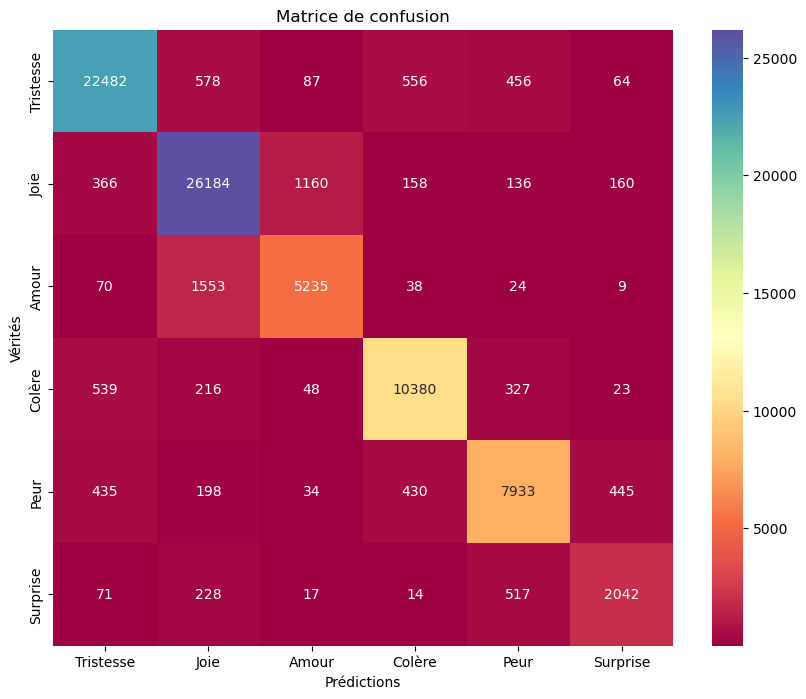

In [101]:
plt.figure(figsize = (10, 8))
sns.heatmap(cmat, annot = True, fmt = "d", cmap = "Spectral", xticklabels = labels, yticklabels = labels)

plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion")
plt.show()

<h5>Observation de la Matrice de confusion</h5>
<ul>
<p>On peut voir que le modèle est très bon sur les émotions suivantes:</p>
<li>joie</li>
<li>Tristesse</li>
<li>Colère</li>
<li>Peur (résultat acceptable)</li>
</ul>
<ul>
<p>Plus compliqué pour ces émotions qui sont moins fréquentes dans le dataset:</p>
<li>Surprise</li>
<li>Amour</li></ul>

In [102]:
import joblib
import numpy as np
import pandas as pd

In [103]:
joblib.dump(pipeline_lr, "../models/model_lr.pkl")

['../models/final_model_lr.pkl']

<h4>Chargement du modèle</h4>

In [107]:
pipeline_lr = joblib.load(r"../models/model_lr.pkl")

<h4>Test du modèle<h4>

In [108]:
texts = [
    "I am so happy",
    "I am angry.",
    "I'm really scared",
    "I feel nothing at all",
    "I feel sad..."
]

df_test = pd.DataFrame({"text" : texts})

df_test

,text
0,I am so happy
1,I am angry.
2,I'm really scared
3,I feel nothing at all
4,I feel sad...


In [109]:
y_pred = pipeline_lr.predict(df_test[["text"]])
print(y_pred)

[1 3 4 1 0]
